In [1]:
!pip install -q sacrebleu rouge-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 15.6 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, embedding, hidden_dim = 512):
        super().__init__()
        self.embedding = embedding
        self.lstm = nn.LSTM(
            input_size = embedding.embedding_dim,
            hidden_size = hidden_dim,
            num_layers = 2,
            bias = True,
            batch_first = True,
            dropout = 0.3,
            bidirectional = True
        )
    def forward(self, source, lengths):
        embedded = self.embedding(source)
        packed_input = torch.nn.utils.rnn.pack_padded_sequence(embedded, lengths, batch_first = True, enforce_sorted = False)
        output, (h,c) = self.lstm(packed_input)
        unpacked_output, _ = torch.nn.utils.rnn.pad_packed_sequence(output, batch_first = True)

        return unpacked_output, h, c


# E = embedding size
# H = encoder hidden dim
# S = source length, T = target length, B = batch size
# V = vocabulary


PAD_ID = 0
BOS_ID = 2
EOS_ID = 3

MAX_DECODE_STEPS = 64

class BahdanauAttention(nn.Module):
    def __init__(self, H):
        super().__init__()
        self.W1 = nn.Linear(H, H)
        self.W2 = nn.Linear(2*H, H)
        self.V = nn.Linear(H, 1)

    def forward(self, query, keys, mask=None):
        query = query.unsqueeze(1) # [B, H] -> [B, 1, H]
        scores = self.V(torch.tanh(self.W1(query) + self.W2(keys))) # [B, S, 1]
        scores = scores.squeeze(-1) # [B, S]

        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)

        attn_w = F.softmax(scores, dim=-1).unsqueeze(1)  # [B, 1, S]
        context_vec = torch.bmm(attn_w, keys) # [B, 1, 2H]

        return context_vec, attn_w


class Decoder(nn.Module):
    def __init__(self, embedding, H, V, E, dropout = 0.1):
        super().__init__()
        self.embedding = embedding
        self.lstm = nn.LSTM(input_size=E + 2*H, num_layers=2, hidden_size=H, batch_first=True, dropout=dropout)
        self.attention = BahdanauAttention(H)
        self.out = nn.Linear(H, V)


    def forward_step(self, inp, hidden, cell, encoder_out, src_mask=None):
        embed = self.embedding(inp) # (B, 1, E)
        query = hidden[-1] # (B, H)
        context, attn = self.attention(query, encoder_out, src_mask) # (B, 1, 2H)
        x = torch.cat([embed, context], dim = -1) # (B, 1, E+2H)

        output, (hidden, cell) = self.lstm(x, (hidden, cell)) # (2, B, H)
        logit = self.out(output) # (B, V)

        return logit, hidden, cell, attn


    def beam_decode(self, encoder_outs, decoder_h, decoder_c, src_mask, beam_size=3, max_steps=32):
        beams = [([BOS_ID], 0.0, decoder_h, decoder_c)]

        for _ in range(max_steps):
            candidates = []

            for tokens, score, hidden, cell in beams:
                if tokens[-1] == EOS_ID:
                    candidates.append((tokens, score, hidden, cell))
                    continue

                decoder_in = torch.tensor([[tokens[-1]]], device=encoder_outs.device)
                out, next_h, next_c, _ = self.forward_step(decoder_in, hidden, cell, encoder_outs, src_mask)

                log_probs = F.log_softmax(out[:, -1, :], dim=-1)
                top_scores, top_ids = torch.topk(log_probs, beam_size, dim=-1)

                for j in range(beam_size):
                    next_id = top_ids[0, j].item()
                    candidates.append((tokens + [next_id], score + top_scores[0, j].item(), next_h, next_c))

            beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_size]

            if all(tokens[-1] == EOS_ID for tokens, _, _, _ in beams):
                break

        return beams[0][0]



    def forward(self, encoder_outs, decoder_h, decoder_c, target=None, src_mask=None):
        B = encoder_outs.size(0)
        decoder_outs = []
        attn_weights = []

        if target is not None:
            decoder_in = target[:, 0].unsqueeze(1)
            steps = target.size(1) - 1

        else:
            decoder_in = torch.full((B,1), BOS_ID, device=encoder_outs.device)
            steps = MAX_DECODE_STEPS

        hidden, cell = decoder_h, decoder_c


        for i in range(steps):
            out, hidden, cell, attn = self.forward_step(decoder_in, hidden, cell, encoder_outs, src_mask)
            decoder_outs.append(out)
            attn_weights.append(attn)

            if target is not None: # training
                decoder_in = target[:, i + 1].unsqueeze(1)
            else: # greedy
                next_token = out[:, -1, :].argmax(dim=-1)
                decoder_in = next_token.unsqueeze(1)

                if torch.all(next_token == EOS_ID):
                    break

        decoder_outs = torch.cat(decoder_outs, dim=1)
        attentions = torch.cat(attn_weights, dim=1)

        return decoder_outs, hidden, cell, attentions

class Bridge(nn.Module):
    def __init__(self, H):
        super().__init__()
        """
        Bridge logic: encoder's h/c come out of nn.LSTM as [num_layers*2, B, H] = [4, B, H] (layer0-fwd, layer0-bwd, layer1-fwd, layer1-bwd, in that order). For each of the 2 layers: concat that layer's fwd+bwd [B,H]+[B,H] → [B,2H], then Linear(2H,H) + tanh → [B,H]. Stack the 2 layers → [2,B,H]. Do this separately for h and c
        """
        self.layer = nn.Linear(2*H, H)

    def forward(self, encoder_h, encoder_c):
        # l0 fwd, lo bwd, l1 fwd, l1 bwd = [B, H] each
        l0 = torch.cat([encoder_h[0], encoder_h[1]], dim=1)
        l1 = torch.cat([encoder_h[2], encoder_h[3]], dim=1)

        c0 = torch.cat([encoder_c[0], encoder_c[1]], dim=1)
        c1 = torch.cat([encoder_c[2], encoder_c[3]], dim=1)

        l0 = torch.tanh(self.layer(l0))
        l1 = torch.tanh(self.layer(l1))
        c0 = torch.tanh(self.layer(c0))
        c1 = torch.tanh(self.layer(c1))

        decoder_h = torch.stack([l0, l1]) # [2, B, H]
        decoder_c = torch.stack([c0, c1]) # [2, B, H]
        return decoder_h, decoder_c



class Seq2SeqModel(nn.Module):
    def __init__(self, in_dim, V, H, E, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(in_dim, E)
        self.encoder = Encoder(self.embedding, H)
        self.bridge = Bridge(H)
        self.decoder = Decoder(self.embedding, H, V, E, dropout)


    def forward(self, source, lengths, target, is_train=True, decoding='greedy', beam_size=3):
        encoder_out, encoder_h, encoder_c = self.encoder(source, lengths)
        decoder_h, decoder_c = self.bridge(encoder_h, encoder_c)
        lens_t = torch.as_tensor(lengths, device=source.device)
        positions = torch.arange(encoder_out.size(1), device=source.device).unsqueeze(0)
        src_mask = positions < lens_t.unsqueeze(1)

        if not is_train and decoding == 'beam':
          return self.decoder.beam_decode(encoder_out, decoder_h, decoder_c, src_mask, beam_size)

        decoder_out, _, _, decoder_attn = self.decoder(encoder_out, decoder_h, decoder_c, target=target if is_train else None, src_mask=src_mask)

        return decoder_out, decoder_attn

In [3]:
import pandas as pd
import numpy as np
import sentencepiece as spm
from torch.utils.data import Dataset, DataLoader
import os
import time

os.makedirs("results", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

train_set = pd.read_csv("/content/data/train.tsv", delimiter='\t', header=None, names=['source', 'target'])
val_set = pd.read_csv("/content/data/valid.tsv", delimiter='\t', header=None, names=['source', 'target'])

# load tokenizer
sp = spm.SentencePieceProcessor('tokenizer/ur_sp.model')

UNK_ID = sp.unk_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()
SP_PAD_ID = sp.pad_id()
VOCAB = sp.get_piece_size()


class UrduDataset(Dataset):
    def __init__(self, df, src_col, tgt_col):
        self.sources = df[src_col].tolist()
        self.targets = df[tgt_col].tolist()


    def __len__(self):
        return len(self.sources)

    def __getitem__(self, idx):
        return (self.sources[idx], self.targets[idx])


def collate_function(batch):
    sources,targets = zip(*batch)

    src_ids = [sp.encode(s, out_type=int) for s in sources]
    tgt_ids = [[BOS_ID] + sp.encode(t, out_type=int) + [EOS_ID] for t in targets]

    src_lens = [len(s) for s in src_ids]
    tgt_lens = [len(t) for t in tgt_ids]

    src_padded = torch.nn.utils.rnn.pad_sequence([torch.tensor(src, dtype=torch.long) for src in src_ids], batch_first=True, padding_value=SP_PAD_ID)
    tgt_padded = torch.nn.utils.rnn.pad_sequence([torch.tensor(tgt, dtype=torch.long) for tgt in tgt_ids], batch_first=True, padding_value=SP_PAD_ID)

    return {
        'src': src_padded,
        'src_lens': src_lens,
        'tgt': tgt_padded,
        'tgt_lens': tgt_lens
    }


train_data = UrduDataset(train_set, src_col="source", tgt_col="target")
val_data = UrduDataset(val_set, src_col="source", tgt_col="target")

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, collate_fn=collate_function)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False, collate_fn=collate_function)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Seq2SeqModel(in_dim=sp.get_piece_size(), V=VOCAB, H=512, E=256, dropout=0.3).to(device)

loss = torch.nn.CrossEntropyLoss(ignore_index=SP_PAD_ID)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, factor=0.5, patience=1)

# train loop
def train_run(model, loader, optim, loss, device):
    model.to(device)
    model.train()

    total_correct, total_tokens = 0, 0
    total_nll = 0.0
    for batch in loader:
        optim.zero_grad()

        src = batch['src'].to(device, non_blocking=True)
        src_lens = batch['src_lens']
        tgt = batch['tgt'].to(device, non_blocking=True)

        out, attn = model(src, src_lens, tgt)
        logits = out # logits: [B, T-1, V]
        labels = tgt[:, 1:] # targets: [B, T-1]

        step_loss = loss(logits.reshape(-1, VOCAB), labels.reshape(-1))
        step_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optim.step()

        pred = logits.detach().argmax(dim=-1)
        mask = (labels != SP_PAD_ID)
        n_tokens = mask.sum().item()
        total_nll += step_loss.item() * n_tokens
        correct = (pred == labels) & mask
        total_correct += correct.sum().item()
        total_tokens += n_tokens

    nll = total_nll / total_tokens
    accuracy = total_correct / total_tokens
    print(f"tr_loss = {nll:.4f} | tr_acc = {accuracy:.4f} | ", end="")

    return nll, accuracy


# validation loop
def val_run(model, loader, loss, device):
    model.to(device)
    model.eval()

    total_correct, total_tokens = 0, 0
    total_nll = 0.0
    with torch.no_grad():
        for batch in loader:
            src = batch['src'].to(device)
            src_lens = batch['src_lens']
            tgt = batch['tgt'].to(device)

            out, attn = model(src, src_lens, tgt, is_train=True)
            logits = out # logits: [B, T-1, V]
            labels = tgt[:, 1:] # targets: [B, T-1]

            step_loss = loss(logits.reshape(-1, VOCAB), labels.reshape(-1))

            pred = logits.detach().argmax(dim=-1)
            mask = (labels != SP_PAD_ID)
            n_tokens = mask.sum().item()
            total_nll += step_loss.item() * n_tokens
            correct = (pred == labels) & mask
            total_correct += correct.sum().item()
            total_tokens += n_tokens

    accuracy = total_correct / total_tokens
    nll = total_nll / total_tokens
    print(f"val_loss = {nll:.4f} | val_acc = {accuracy:.4f}")

    return nll, accuracy


def train_model(model, train_loader, val_loader, optimizer, loss, device, epochs):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_loss = float("inf")
    patience, counter = 5, 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        tr_loss, tr_acc = train_run(model, train_loader, optimizer, loss, device)
        train_losses.append(tr_loss)
        train_accs.append(tr_acc)

        val_loss, val_acc = val_run(model, val_loader, loss, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        sched.step(val_loss)

        if val_loss < best_val_loss:
            torch.save(model.state_dict(), '/content/checkpoints/best_model.pt')
            best_val_loss = val_loss
            counter = 0
        else:
            counter += 1

        if counter > patience:
            print("Early stooping at epoch", epoch)
            break

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs,
    }

start = time.time()
history = train_model(model, train_loader, val_loader, optim, loss, device='cuda' if torch.cuda.is_available() else 'cpu', epochs=15)
wall_clock = time.time() - start

pd.DataFrame(history).to_csv("results/training_history.csv", index=False)



Epoch 1/15
tr_loss = 5.0765 | tr_acc = 0.2283 | val_loss = 4.5810 | val_acc = 0.2755

Epoch 2/15
tr_loss = 4.1889 | tr_acc = 0.3085 | val_loss = 4.2119 | val_acc = 0.3087

Epoch 3/15
tr_loss = 3.8305 | tr_acc = 0.3422 | val_loss = 4.0360 | val_acc = 0.3259

Epoch 4/15
tr_loss = 3.5917 | tr_acc = 0.3648 | val_loss = 3.9359 | val_acc = 0.3376

Epoch 5/15
tr_loss = 3.3841 | tr_acc = 0.3844 | val_loss = 3.8583 | val_acc = 0.3474

Epoch 6/15
tr_loss = 3.1885 | tr_acc = 0.4025 | val_loss = 3.8057 | val_acc = 0.3542

Epoch 7/15
tr_loss = 3.0120 | tr_acc = 0.4205 | val_loss = 3.7962 | val_acc = 0.3571

Epoch 8/15
tr_loss = 2.8491 | tr_acc = 0.4387 | val_loss = 3.7938 | val_acc = 0.3617

Epoch 9/15
tr_loss = 2.7010 | tr_acc = 0.4564 | val_loss = 3.8137 | val_acc = 0.3615

Epoch 10/15
tr_loss = 2.5650 | tr_acc = 0.4731 | val_loss = 3.8486 | val_acc = 0.3649

Epoch 11/15
tr_loss = 2.3475 | tr_acc = 0.5051 | val_loss = 3.8751 | val_acc = 0.3663

Epoch 12/15
tr_loss = 2.2418 | tr_acc = 0.5217 | va

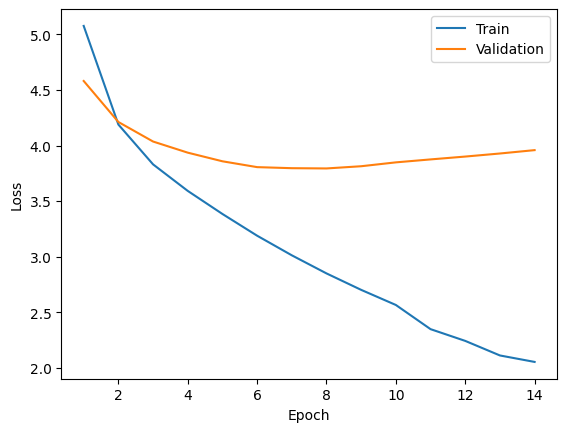

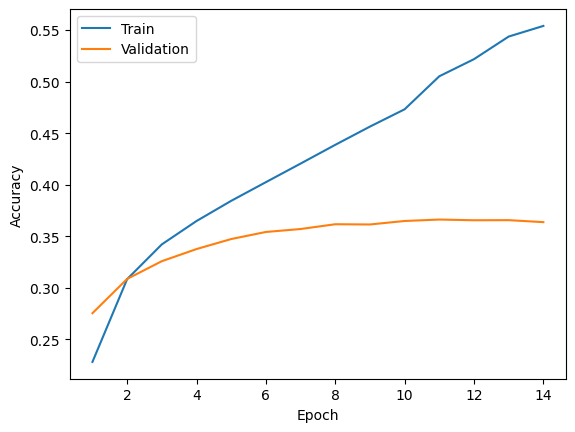

In [4]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train")
plt.plot(epochs, history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("results/loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(epochs, history["train_acc"], label="Train")
plt.plot(epochs, history["val_acc"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("results/accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
config = pd.DataFrame([{
    "encoder": "2-layer BiLSTM",
    "decoder": "2-layer LSTM + Bahdanau attention",
    "embedding_dim": 256,
    "hidden_dim": 512,
    "vocab_size": VOCAB,
    "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
    "optimizer": "Adam",
    "learning_rate": optim.param_groups[0]["lr"],
    "schedule": "None",
    "batch_size": train_loader.batch_size,
    "epochs": 15,
    "wall_clock_seconds": wall_clock,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
}])

config.to_csv("results/model_config.csv", index=False)
config

,encoder,decoder,embedding_dim,hidden_dim,vocab_size,trainable_parameters,optimizer,learning_rate,schedule,batch_size,epochs,wall_clock_seconds,gpu
0,2-layer BiLSTM,2-layer LSTM + Bahdanau attention,256,512,8000,22693697,Adam,0.000125,None,64,15,2637.70288,NVIDIA L4


In [6]:
ANS_OPEN, ANS_CLOSE = "<ans>", "</ans>"
SENT_DELIMS = "\u06D4\u061F!"

def split_sentences(text):
    start = 0
    for i, ch in enumerate(text):
        if ch in SENT_DELIMS:
            yield start, i + 1, text[start:i + 1]
            start = i + 1
    if start < len(text):
        yield start, len(text), text[start:]

def make_pair(example, max_src=60, max_tgt=25):
    a_text = example["answer"]
    if not a_text:
        return None
    context = example["context"]
    a_start = example["answer_start"]
    if a_start == -1:
        return None
    for s, e, sent in split_sentences(context):
        if s <= a_start < e:
            rel = a_start - s
            if sent[rel:rel + len(a_text)] != a_text:
                return None
            src = (sent[:rel] + " " + ANS_OPEN + " " + a_text + " "
                   + ANS_CLOSE + " " + sent[rel + len(a_text):]).strip()
            src = " ".join(src.split())
            tgt = " ".join(example["question"].split())
            if len(src.split()) > max_src or len(tgt.split()) > max_tgt:
                return None
            return src, tgt
    return None

In [7]:
import sacrebleu
from rouge_score import rouge_scorer
import torch
import torch.nn as nn
import torch.nn.functional as F
import sentencepiece as spm
from datasets import load_dataset
import unicodedata
from torch.utils.data import Dataset, DataLoader

sp = spm.SentencePieceProcessor('/content/tokenizer/ur_sp.model')

UNK_ID = sp.unk_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()
SP_PAD_ID = sp.pad_id()
VOCAB = sp.get_piece_size()

class TestDataset(Dataset):
    def __init__(self, pairs):
        self.ex = []

        for src, tgt in pairs:
            srce_ids = sp.encode(src, out_type=int)
            tgt_ids = ([BOS_ID] + sp.encode(tgt, out_type=int) + [EOS_ID])
            self.ex.append({
                'src_ids': srce_ids,
                'tgt_ids': tgt_ids,
                'src_text': src,
                'tgt_text': tgt
            })

    def __len__(self):
        return len(self.ex)

    def __getitem__(self, idx):
        return self.ex[idx]


class UrduTokenizer:
    def tokenize(self, text):
        text = "".join(
            c if c.isalnum() or unicodedata.category(c).startswith("M") else " "
            for c in text.lower()
        )
        return text.split()



def test_collate(batch):
    src_ids = [torch.tensor(ex['src_ids']) for ex in batch]
    tgt_ids = [torch.tensor(ex['tgt_ids']) for ex in batch]

    src_lens = [len(s) for s in src_ids]
    src_pad = nn.utils.rnn.pad_sequence(src_ids, batch_first=True, padding_value=SP_PAD_ID)
    tgt_pad = nn.utils.rnn.pad_sequence(tgt_ids, batch_first=True, padding_value=SP_PAD_ID)

    return {
        "src": src_pad,
        "src_lens": src_lens,
        "tgt": tgt_pad,
        "src_text": [ex["src_text"] for ex in batch],
        "tgt_text": [ex["tgt_text"] for ex in batch],
    }


def score(hyps, refs):
    bleu = sacrebleu.corpus_bleu(hyps, [refs]).score
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False, tokenizer=UrduTokenizer())
    rl = sum(scorer.score(r, h)["rougeL"].fmeasure  for h, r in zip( hyps , refs ) ) / len( refs )
    unk_rate = sum(h.count("\u2047") for h in hyps ) / max(1, sum(len( h . split ()) for h in hyps))

    return {'BLEU-4': bleu, 'ROUGE-L': rl, 'unk_rate': unk_rate}


def test_model(model, loader, loss, device):
    model.to(device)
    model.eval()
    total_loss = 0
    total_correct = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in loader:
            src = batch['src'].to(device)
            src_lens = batch['src_lens']
            tgt = batch['tgt'].to(device)

            out, attn = model(src, src_lens, tgt, is_train=True)
            logits = out # [B, T-1, V]
            labels = tgt[:, 1:] # [B, T-1]

            step_loss = loss(logits.reshape(-1, VOCAB), labels.reshape(-1))
            mask = (labels != SP_PAD_ID)
            n_tokens = mask.sum().item()
            total_loss += step_loss.item() * n_tokens

            pred = logits.detach().argmax(dim=-1)
            correct = (pred == labels) & mask
            total_correct += correct.sum().item()
            total_tokens += n_tokens

    accuracy = total_correct / total_tokens
    nll = total_loss / total_tokens
    perplexity = torch.exp(torch.tensor(nll)).item()

    print(
        f"test_loss = {nll:.4f} | "
        f"test_ppl = {perplexity:.4f} | "
        f"test_acc = {accuracy:.4f}"
    )

    return nll, perplexity, accuracy


# BLEU score, ROUGEL, unknown rate
def decode_ids(ids):
    if torch.is_tensor(ids):
        ids = ids.tolist()
    if EOS_ID in ids:
        ids = ids[:ids.index(EOS_ID)]
    ids = [tkn for tkn in ids if tkn not in {BOS_ID, SP_PAD_ID, EOS_ID}]
    return sp.decode(ids)


def greedy_decode(model, loader, device):
    model.eval()
    hyps, refs, srcs = [], [], []

    with torch.no_grad():
        for batch in loader:
            src = batch['src'].to(device)
            src_lens = batch['src_lens']

            out, attn = model(src, src_lens, target=None, is_train=False)
            pred = out.argmax(dim=-1)
            for ids in pred:
                hyps.append(decode_ids(ids))

            refs.extend(batch['tgt_text'])
            srcs.extend(batch['src_text'])

    return srcs, hyps, refs


def beam_decode(model, loader, device, beam_size=3):
  model.eval()
  hyps = []

  with torch.no_grad():
    for batch in loader:
      for i in range(len(batch['src_lens'])):
          src = batch['src'][i:i+1].to(device)
          ids = model(src, [batch['src_lens'][i]], target=None, is_train=False, decoding='beam', beam_size=beam_size)
          hyps.append(decode_ids(ids))

  return hyps


# load best model
uqa = load_dataset("uqa/UQA", split="validation")
wuqa = load_dataset("uqa/Wiki-UQA", split="train")

uqa_pairs = [pair for ex in uqa if (pair := make_pair(ex)) is not None]
wuqa_pairs = [pair for ex in wuqa if (pair := make_pair(ex)) is not None]

print(f"UQA validation pairs: {len(uqa_pairs)}")
print(f"Wiki-UQA pairs: {len(wuqa_pairs)}")


README.md:   0%|          | 0.00/898 [00:00<?, ?B/s]

data/train-00000-of-00001-bac007e8ca7192(…): reconstructing file:   0%|          |  0.00B / 30.2MB            

data/train-00000-of-00001-bac007e8ca7192(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-cf8a6960d(…): reconstructing file:   0%|          |  0.00B / 2.92MB            

data/validation-00000-of-00001-cf8a6960d(…): downloading bytes:           |  0.00B            

...

README.md:   0%|          | 0.00/489 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 76.0kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/210 [00:00<?, ? examples/s]

UQA validation pairs: 10018
Wiki-UQA pairs: 177


In [8]:
uqa_train = load_dataset("uqa/UQA", split="train")

stats = pd.DataFrame({
    "split": ["Train", "UQA validation", "Wiki-UQA"],
    "raw_rows": [len(uqa_train), len(uqa), len(wuqa)],
    "answerable_rows": [
        sum(bool(x["answer"]) for x in uqa_train),
        sum(bool(x["answer"]) for x in uqa),
        sum(bool(x["answer"]) for x in wuqa)
    ],
    "pairs_after_filter": [len(train_set), len(uqa_pairs), len(wuqa_pairs)],
    "mean_source_length": [
        train_set["source"].str.split().str.len().mean(),
        np.mean([len(s.split()) for s, _ in uqa_pairs]),
        np.mean([len(s.split()) for s, _ in wuqa_pairs])
    ],
    "mean_target_length": [
        train_set["target"].str.split().str.len().mean(),
        np.mean([len(t.split()) for _, t in uqa_pairs]),
        np.mean([len(t.split()) for _, t in wuqa_pairs])
    ]
})

stats.to_csv("results/dataset_stats.csv", index=False)
stats

,split,raw_rows,answerable_rows,pairs_after_filter,mean_source_length,mean_target_length
0,Train,124745,83018,75003,32.648907,11.919590
1,UQA validation,16824,11169,10018,33.228589,12.288381
2,Wiki-UQA,210,210,177,31.694915,11.423729


In [9]:
uqa_data_test = TestDataset(uqa_pairs)
wuqa_data_test = TestDataset(wuqa_pairs)

uqa_testloader = DataLoader(uqa_data_test, batch_size=64, shuffle=False, collate_fn=test_collate, pin_memory=True)
wuqa_testloader = DataLoader(wuqa_data_test, batch_size=64, shuffle=False, collate_fn=test_collate, pin_memory=True)

In [10]:
model = Seq2SeqModel(in_dim=VOCAB, V=VOCAB, H=512, E=256, dropout=0.3)
state_dict = torch.load('/content/checkpoints/best_model.pt', map_location=device)
model.load_state_dict(state_dict)
model.to(device)

model.eval()
loss = nn.CrossEntropyLoss(ignore_index=SP_PAD_ID)

print("Results on UQA evaluation:")
uqa_loss, uqa_ppl, uqa_acc = test_model(model, uqa_testloader, loss, device)
print("\nResults on Wiki-UQA evaluation:")
wqa_loss, wqa_ppl, wqa_acc = test_model(model, wuqa_testloader, loss, device)

Results on UQA evaluation:
test_loss = 3.8123 | test_ppl = 45.2529 | test_acc = 0.3613

Results on Wiki-UQA evaluation:
test_loss = 4.4183 | test_ppl = 82.9526 | test_acc = 0.2852


In [11]:
uqa_srcs, uqa_greedy, uqa_refs = greedy_decode(model, uqa_testloader, device)
wqa_srcs, wqa_greedy, wqa_refs = greedy_decode(model, wuqa_testloader, device)

uqa_beam = beam_decode(model, uqa_testloader, device, beam_size=3)
wqa_beam = beam_decode(model, wuqa_testloader, device, beam_size=3)
print("Beam decode done.")

uqa_scores_greedy = score(uqa_greedy, uqa_refs)
uqa_scores_beam = score(uqa_beam, uqa_refs)
print("UQA Decoding eval done..")

wqa_scores_greedy = score(wqa_greedy, wqa_refs)
wqa_scores_beam = score(wqa_beam, wqa_refs)
print("WQA decoding eval done.")

print("\nUQA validation (Greedy)")
print("PPL:", uqa_ppl)
print(uqa_scores_greedy)

print("\nUQA validation (Beam)")
print("PPL:", uqa_ppl)
print(uqa_scores_beam)

print("\nWiki-UQA validation (Greedy)")
print("PPL:", wqa_ppl)
print(wqa_scores_greedy)

print("\nWiki-UQA validation (Beam)")
print("PPL:", wqa_ppl)
print(wqa_scores_beam)

Beam decode done.
UQA Decoding eval done..
WQA decoding eval done.

UQA validation (Greedy)
PPL: 45.252925872802734
{'BLEU-4': 1.2931596314230813, 'ROUGE-L': 0.16212264860293052, 'unk_rate': 0.04891118648587834}

UQA validation (Beam)
PPL: 45.252925872802734
{'BLEU-4': 1.5823448491053345, 'ROUGE-L': 0.1722779144729135, 'unk_rate': 0.03885647941072907}

Wiki-UQA validation (Greedy)
PPL: 82.95258331298828
{'BLEU-4': 0.6229677301101157, 'ROUGE-L': 0.14685571516237123, 'unk_rate': 0.0648720211827008}

Wiki-UQA validation (Beam)
PPL: 82.95258331298828
{'BLEU-4': 0.7384836686955528, 'ROUGE-L': 0.13858613041146384, 'unk_rate': 0.05797845048742945}


In [12]:
metrics = pd.DataFrame([
    ["UQA valid", "greedy", uqa_scores_greedy["BLEU-4"], uqa_scores_greedy["ROUGE-L"], uqa_ppl, 100 * uqa_scores_greedy["unk_rate"]],
    ["UQA valid", "beam (k=3)", uqa_scores_beam["BLEU-4"], uqa_scores_beam["ROUGE-L"], uqa_ppl, 100 * uqa_scores_beam["unk_rate"]],
    ["Wiki-UQA", "greedy", wqa_scores_greedy["BLEU-4"], wqa_scores_greedy["ROUGE-L"], wqa_ppl, 100 * wqa_scores_greedy["unk_rate"]],
    ["Wiki-UQA", "beam (k=3)", wqa_scores_beam["BLEU-4"], wqa_scores_beam["ROUGE-L"], wqa_ppl, 100 * wqa_scores_beam["unk_rate"]],
], columns=["split", "decoding", "BLEU-4", "ROUGE-L", "PPL", "unk_%"])

metrics.to_csv("results/automatic_metrics.csv", index=False)
metrics

,split,decoding,BLEU-4,ROUGE-L,PPL,unk_%
0,UQA valid,greedy,1.293160,0.162123,45.252926,4.891119
1,UQA valid,beam (k=3),1.582345,0.172278,45.252926,3.885648
2,Wiki-UQA,greedy,0.622968,0.146856,82.952583,6.487202
3,Wiki-UQA,beam (k=3),0.738484,0.138586,82.952583,5.797845


In [13]:
samples = pd.DataFrame({
    "source": uqa_srcs,
    "reference": uqa_refs,
    "greedy": uqa_greedy,
    "beam": uqa_beam
})

samples = samples.sample(50, random_state=42)
samples.to_csv("results/samples.tsv", sep="\t", index=False)
samples

,source,reference,greedy,beam
1617,معیاری درجہ حرارت اور دباؤ پر ، عنصر کے <ans> ...,ڈائی آکسجن بنانے کے لیے کتنے ایٹم ملتے ہیں؟,جب ہائیڈروجن گیس کی لمبائی میں منتقل ہوتا ہے ت...,ہائیڈروجن گیس میں کتنے اجزاء ہوتے ہیں؟
4952,ان میں پارچیکل اسکول شامل ہیں ، ایک اصطلاح جو ...,اصطلاح 'پروچیکل اسکول' عام طور پر کس مذہب کے ا...,"کون سا اصطلاح ⁇ ""سیاہ ⁇ "" کے طور پر جانا جاتا...",ہندو مذہب میں خدا کی ایک مثال کیا ہے؟
2168,<ans> 15 اگست ، 1971 </ans> کو ، ریاستہائے متح...,ریاستہائے متحدہ امریکہ نے بریٹن ووڈس معاہدے سے...,کس سال میں Jiangs کے ساتھ ایک ساتھ شروع ہوا؟,ریاستہائے متحدہ نے کس تاریخ کو مردم شماری کی؟
1090,نینٹس کے حکم نامے کی منسوخی کے بعد ، ڈچ جمہوری...,کتنے پناہ گزین ڈچ جمہوریہ میں ہجرت کی؟,"⁇ ""آگیا کی آبادی ⁇ "" میں کتنے لوگ رہتے تھے؟","⁇ ""مقافت سلطنت کی آبادی کتنی تھی؟"
7986,اولیور روئے کا استدلال ہے کہ سنی پان اسلام پسن...,سلفی تحریک نے کس چیز پر زور دیا؟,کون سا نظریہ یقین رکھتا تھا کہ خدا نے اپنے آپ ...,نشاۃ ثانیہ کے نظریہ نے کس قسم کی سوچ کو متاثر ...
8075,وقتا فوقتا جبر کے باوجود ، اخوان المسلمون اسلا...,اسلامی دنیا میں اخوان المسلمون نے کیا حیثیت حا...,کون سا گروپ سب سے زیادہ مقبول ہے؟,"⁇ ""سیاہ ⁇ "" کا کیا مطلب ہے؟"
2236,آمدنی کا کچھ حصہ دیگر کم ترقی یافتہ ممالک کی ا...,تیل کی آمدنی سے کم ترقی یافتہ ممالک کو امداد م...,کیا میانمار کی معیشت میں کمی آئی ہے؟,کیا میانمار کی معیشت میں کمی آئی ہے؟
7228,رائن کی لمبائی روایتی طور پر رائن کلومیٹر (رائ...,دریائے رائن کی پیمائش کہاں سے شروع ہوتی ہے؟,"کس دور میں ⁇ ""آگمین ⁇ "" کی اصطلاح سب سے زیادہ...","کس دور میں ⁇ ""آگمین ⁇ "" کی بنیاد رکھی گئی تھی؟"
6925,فرمیٹ نے یہ بھی قیاس کیا کہ 22n + 1 کی شکل کے ...,فرمیٹ نے فرمیٹ نمبروں کی صداقت کی تصدیق کس حد ...,"⁇ ""مقافت ⁇ "" کی اصطلاح کیا تھی؟","⁇ ""محقہ ⁇ "" کا کیا مطلب ہے؟"
6723,وہ فیصلہ کرتے ہیں کہ عالمی اوسط سطح کے ہوا کا ...,گزشتہ صدی میں عالمی سطح پر ہوا کا اوسط درجہ حر...,"ایک ⁇ ""بگ ⁇ "" کتنا لمبا ہے؟",امریکہ میں سب سے زیادہ بارش کیا ہے؟


/tmp/ipykernel_1222/2423232215.py:23: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1222/2423232215.py:23: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_1222/2423232215.py:23: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1222/2423232215.py:23: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1222/2423232215.py:24: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig("results/attention_heatmap.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_1222/2423232215.py:24: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig("results/attention_heatmap.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_1222/2423232215.py:24: UserWarning: Gly

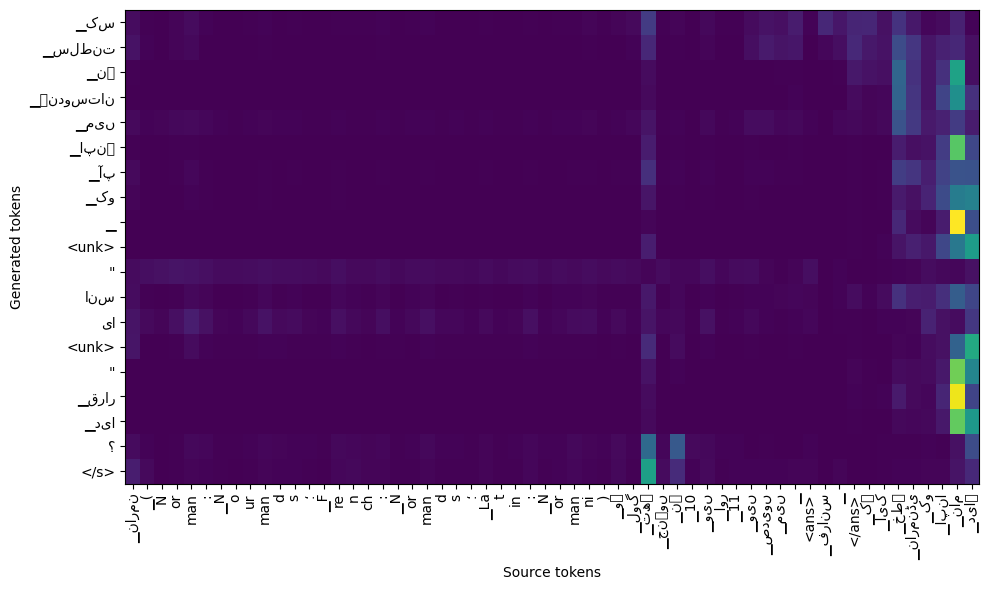

In [14]:
batch = next(iter(uqa_testloader))
src = batch["src"].to(device)

with torch.no_grad():
    out, attn = model(src, batch["src_lens"], target=None, is_train=False)

i = 0
pred = out[i].argmax(-1)
src_ids = src[i, :batch["src_lens"][i]].cpu().tolist()
pred_ids = pred.cpu().tolist()

if EOS_ID in pred_ids:
    pred_ids = pred_ids[:pred_ids.index(EOS_ID) + 1]

A = attn[i, :len(pred_ids), :len(src_ids)].cpu().numpy()

plt.figure(figsize=(10, 6))
plt.imshow(A, aspect="auto")
plt.xticks(range(len(src_ids)), [sp.id_to_piece(x) for x in src_ids], rotation=90)
plt.yticks(range(len(pred_ids)), [sp.id_to_piece(x) for x in pred_ids])
plt.xlabel("Source tokens")
plt.ylabel("Generated tokens")
plt.tight_layout()
plt.savefig("results/attention_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
def inspect_batch(model, loader, device, n=5):
    model.eval()
    batch = next(iter(loader))

    src = batch["src"][:n].to(device)
    src_lens = batch["src_lens"][:n]
    tgt = batch["tgt"][:n]

    with torch.no_grad():
        out, attn = model(
            src, src_lens,
            target=None,
            is_train=False
        )

    pred = out.argmax(-1)

    for i in range(n):
        print(f"\n--- Example {i} ---")
        print("SRC :", decode_ids(src[i]))
        print("REF :", decode_ids(tgt[i]))
        print("PRED:", decode_ids(pred[i]))

In [16]:
print("TRAIN")
inspect_batch(model, train_loader, device)

print("\nUQA")
inspect_batch(model, uqa_testloader, device)

TRAIN

--- Example 0 ---
SRC : یونیورسٹی میں تمام 50 امریکی ریاستوں اور <ans> 120 </ans> سے زیادہ ممالک کے طلباء اور فیکلٹی ہیں۔
REF : واشنگٹن یونیورسٹی کے فیکلٹی اور طلباء کی تشکیل میں کتنے مختلف ممالک شامل ہیں؟
PRED: واشنگٹن یونیورسٹی میں کتنے طلباء ہیں؟

--- Example 1 ---
SRC : مذکورہ بالا سب کے علاوہ ، دماغ اور ریڑھ کی ہڈی میں <ans> خود مختار اعصابی نظام </ans> کو کنٹرول کرنے کے لئے وسیع سرکٹری موجود ہے ، جو ہارمونز کو خارج کرکے اور آنت کے ہموار پٹھوں کو ماڈیولنگ کرکے کام کرتا ہے۔
REF : جسم میں کون سا نظام لعاب کو کنٹرول کرتا ہے؟
PRED: ایک درخت کے درخت میں، ایک اور نام کیا ہے؟

--- Example 2 ---
SRC : 9 ستمبر ، ایپل ایونٹ میں <ans> 2009 </ans> کی کلیدی پریزنٹیشن میں ، فل شیلر نے اعلان کیا کہ آئی پوڈ کی مجموعی مجموعی فروخت 220 ملین سے تجاوز کر گئی ہے۔
REF : کس سال سے آئی پوڈ کی خریداری میں مسلسل کمی آنا شروع ہوئی؟
PRED: کس سال میں ایپل نے اپنے پیٹنٹ کی ترسیل کی؟

--- Example 3 ---
SRC : <ans> کورس </ans> (کوروس) وسیع تر گروپس ہیں جو گلیوں میں گٹاروں اور لوتھوں کے آرکسٹرا کے ساتھ گات

In [17]:
batch = next(iter(uqa_testloader))

src = batch["src"][:5].to(device)
lengths = batch["src_lens"][:5]

model.eval()

with torch.no_grad():
    enc_out, enc_h, enc_c = model.encoder(src, lengths)
    dec_h, dec_c = model.bridge(enc_h, enc_c)

    lens = torch.tensor(lengths, device=device)
    pos = torch.arange(enc_out.size(1), device=device).unsqueeze(0)
    mask = pos < lens.unsqueeze(1)

    bos = torch.full((len(lengths), 1), BOS_ID, device=device)

    logits, _, _, _ = model.decoder.forward_step(
        bos, dec_h, dec_c, enc_out, mask
    )

    probs = logits[:, -1].softmax(-1)
    values, ids = probs.topk(5, dim=-1)

for i in range(5):
    print(f"\nExample {i}")
    for token_id, p in zip(ids[i], values[i]):
        print(
            repr(sp.id_to_piece(token_id.item())),
            f"{p.item():.4f}"
        )


Example 0
'▁کس' 0.0612
'▁' 0.0556
'▁کون' 0.0261
'▁ہی' 0.0153
'▁بازنطینی' 0.0128

Example 1
'▁کس' 0.0799
'▁نپولین' 0.0444
'▁ہی' 0.0223
'▁روم' 0.0197
'▁' 0.0183

Example 2
'▁نپولین' 0.0412
'▁کس' 0.0374
'▁ورجل' 0.0333
'▁وائٹ' 0.0240
'▁ابن' 0.0231

Example 3
'▁کس' 0.1158
'▁کون' 0.1066
'▁اس' 0.0277
'▁' 0.0260
'▁جان' 0.0210

Example 4
'▁کس' 0.0999
'▁کون' 0.0907
'▁اس' 0.0261
'▁جان' 0.0240
'▁' 0.0213


In [18]:
print(
    "Mean logit std across examples:",
    logits[:, -1, :].std(dim=0).mean().item()
)

Mean logit std across examples: 0.7974854111671448


In [19]:
batch = next(iter(uqa_testloader))

src = batch["src"][:3].to(device)
lengths = batch["src_lens"][:3]

with torch.no_grad():
    out, attn = model(
        src,
        lengths,
        target=None,
        is_train=False
    )

pred = out.argmax(-1)

for i in range(3):
    print(f"\n--- Example {i} ---")
    print("Prediction:", decode_ids(pred[i]))

    for t in range(min(8, attn.size(1))):
        pos = attn[i, t, :lengths[i]].argmax().item()
        token_id = src[i, pos].item()

        print(
            f"step {t:2d} ->",
            sp.id_to_piece(token_id),
            f"attention={attn[i,t,pos].item():.3f}"
        )


--- Example 0 ---
Prediction: کس سلطنت نے ہندوستان میں اپنے آپ کو  ⁇ "انسیا ⁇ " قرار دیا؟
step  0 -> ▁تھے attention=0.115
step  1 -> ▁خطے attention=0.154
step  2 -> ▁نام attention=0.386
step  3 -> ▁نام attention=0.332
step  4 -> ▁خطے attention=0.171
step  5 -> ▁نام attention=0.494
step  6 -> ▁نام attention=0.170
step  7 -> ▁دیا۔ attention=0.294

--- Example 1 ---
Prediction: کس صدی میں عثمانیوں نے اپنے آپ کو ایک بار پھر ایک بار پھر کیا؟
step  0 -> ▁فرانس attention=0.171
step  1 -> ▁تھے attention=0.121
step  2 -> ▁نام attention=0.246
step  3 -> ▁نام attention=0.118
step  4 -> ▁خطے attention=0.106
step  5 -> ▁نام attention=0.470
step  6 -> ▁خطے attention=0.164
step  7 -> ▁نام attention=0.259

--- Example 2 ---
Prediction: نپولین نے کس صدی میں اپنی حکمرانی کے دوران اپنی موت کا آغاز کیا؟
step  0 -> ▁تھے attention=0.223
step  1 -> ▁تھے attention=0.155
step  2 -> </ans> attention=0.186
step  3 -> ▁فرانس attention=0.208
step  4 -> ▁نام attention=0.638
step  5 -> ▁نام attention=0.319
step  6 

In [20]:
batch = next(iter(train_loader))

src = batch["src"].to(device)
lengths = batch["src_lens"]
tgt = batch["tgt"].to(device)

model.train()
model.zero_grad(set_to_none=True)

out, _ = model(src, lengths, tgt, is_train=True)

labels = tgt[:, 1:]
L = loss(
    out.reshape(-1, VOCAB),
    labels.reshape(-1)
)

L.backward()

for name, module in [
    ("embedding", model.embedding),
    ("encoder", model.encoder),
    ("bridge", model.bridge),
    ("attention", model.decoder.attention),
    ("decoder_lstm", model.decoder.lstm),
    ("output", model.decoder.out),
]:
    grads = [
        p.grad.norm().item()
        for p in module.parameters()
        if p.grad is not None
    ]

    print(
        f"{name:12s}",
        f"mean={np.mean(grads):.6f}",
        f"max={np.max(grads):.6f}"
    )

model.zero_grad(set_to_none=True)

embedding    mean=0.036306 max=0.036306
encoder      mean=0.024696 max=0.108852
bridge       mean=0.019644 max=0.034335
attention    mean=0.008690 max=0.021175
decoder_lstm mean=0.060451 max=0.126272
output       mean=0.141042 max=0.254991


In [21]:
total = 0
unks = 0

for _, tgt in train_set.itertuples(index=False):
    ids = sp.encode(tgt, out_type=int)
    total += len(ids)
    unks += sum(x == UNK_ID for x in ids)

print("Target tokens:", total)
print("UNK tokens:", unks)
print("UNK rate:", unks / total)

Target tokens: 1072038
UNK tokens: 2550
UNK rate: 0.0023786470255718548


In [22]:
batch = next(iter(uqa_testloader))

src = batch["src"][:16].to(device)
lengths = batch["src_lens"][:16]

with torch.no_grad():
    out, attn = model(
        src,
        lengths,
        target=None,
        is_train=False
    )

for i in range(5):
    L = lengths[i]
    a = attn[i, :, :L]

    print(
        f"Example {i}:",
        f"mean max={a.max(dim=-1).values.mean().item():.4f}",
        f"uniform={1/L:.4f}"
    )

Example 0: mean max=0.2982 uniform=0.0172
Example 1: mean max=0.3133 uniform=0.0175
Example 2: mean max=0.2396 uniform=0.0179
Example 3: mean max=0.2650 uniform=0.0169
Example 4: mean max=0.2194 uniform=0.0169


In [23]:
batch = next(iter(uqa_testloader))

src = batch["src"][:5].to(device)
lengths = batch["src_lens"][:5]

with torch.no_grad():
    out, _ = model(
        src,
        lengths,
        target=None,
        is_train=False
    )

probs = out.softmax(-1)

for i in range(5):
    eos_probs = probs[i, :, EOS_ID]
    unk_probs = probs[i, :, UNK_ID]

    print(
        f"Example {i}:",
        f"max EOS={eos_probs.max().item():.4f}",
        f"max UNK={unk_probs.max().item():.4f}",
        f"final EOS={eos_probs[-1].item():.4f}"
    )

Example 0: max EOS=0.9998 max UNK=0.7971 final EOS=0.9998
Example 1: max EOS=0.9998 max UNK=0.1022 final EOS=0.9998
Example 2: max EOS=0.9999 max UNK=0.0004 final EOS=0.9999
Example 3: max EOS=0.9994 max UNK=0.0749 final EOS=0.9994
Example 4: max EOS=0.9999 max UNK=0.0001 final EOS=0.9998
